In [4]:
# %load_ext autoreload
# %autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import skopi as sk

import torch
from tqdm import tqdm 
import time
import h5py

from neurorient import uniform_points_on_sphere
from neurorient.reconstruction.slicing import get_reciprocal_mesh, get_real_mesh
import scipy

import os, glob
os.environ["USE_CUPY"] = "1"
os.environ.get('USE_CUPY')

'1'

In [1]:
data_type = '7K_iUCrJ_downsampled_128x128'

img_size = 128

In [2]:
data_path = '/pscratch/sd/z/zhantao/neurorient_repo/data/PR772_processed/reconstructionData'
save_dir = '/pscratch/sd/z/zhantao/neurorient_repo/data/PR772_processed/rdy_to_use'

In [5]:
_h5_file = '/pscratch/sd/z/zhantao/neurorient_repo/data/PR772_processed/amo86615_PR772_7k_PCA_7303.h5'

with h5py.File(_h5_file, "r") as f:
    print(f.keys())
    images = f['photonConverter/pnccdBack/photonCount'][:]
    # photons.append(_photons)
images = images[:,1:-2,:]

<KeysViewHDF5 ['angularAverage', 'chiSquare', 'hitFinder', 'p', 'particleCorrelator', 'particleSize', 'photonConverter']>


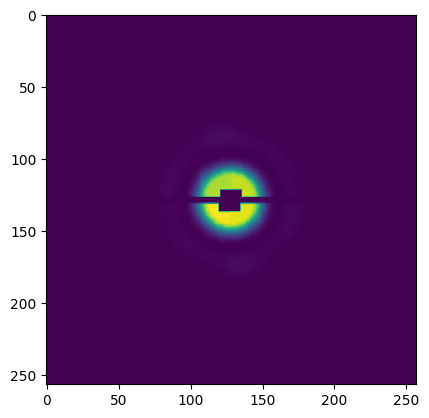

In [6]:
plt.imshow(images[0])

In [7]:
print(images.shape)

(7303, 257, 257)


In [8]:
det = np.loadtxt('input/dragonfly/det_pnccd_back.dat', skiprows=1)
det_shape = (260, 257)

In [9]:
pixel_position_reciprocal = 1e7 * det[:,:3].reshape((1,)+det_shape+(3,))
pixel_position_reciprocal = pixel_position_reciprocal[:,1:-2,:,:]

In [15]:
torch.from_numpy(det).abs().max() * 1e-9 

tensor(4.2999e-08, dtype=torch.float64)

In [ ]:
det[:,:3]

array([[-4.29069943e+01, -4.24100020e+01, -2.80576182e+00,
         2.57581458e-07,  2.00000000e+00],
       [-4.29084158e+01, -4.20800680e+01, -2.78432027e+00,
         2.57606985e-07,  2.00000000e+00],
       [-4.29098263e+01, -4.17501012e+01, -2.76304477e+00,
         2.57632316e-07,  2.00000000e+00],
       ...,
       [ 4.29098263e+01,  4.17501012e+01, -2.76304477e+00,
         2.57632316e-07,  2.00000000e+00],
       [ 4.29084158e+01,  4.20800680e+01, -2.78432027e+00,
         2.57606985e-07,  2.00000000e+00],
       [ 4.29069943e+01,  4.24100020e+01, -2.80576182e+00,
         2.57581458e-07,  2.00000000e+00]])

In [ ]:
img_real_mesh = get_real_mesh(min(det_shape), pixel_position_reciprocal.max())
_mesh = get_reciprocal_mesh(min(det_shape), pixel_position_reciprocal.max())
vol_real_mesh = get_real_mesh(_mesh.shape[0], _mesh.max())

In [ ]:
idx_xx, idx_yy = np.meshgrid(np.arange(img_size), np.arange(img_size))

In [ ]:
pixel_index_map = np.concatenate([idx_xx[None,...,None], idx_yy[None,...,None]], axis=-1)

In [ ]:
zoom_ratio = img_size / min(det_shape)

images_downsampled = np.zeros((images.shape[0], img_size, img_size))

In [ ]:
for i in tqdm(range(images.shape[0])):
    img = images[i]
    img_downsampled = scipy.ndimage.zoom(img, zoom_ratio, order=1)
    images_downsampled[i] = img_downsampled

100%|██████████| 7303/7303 [00:03<00:00, 2253.61it/s]


In [ ]:
pixel_position_reciprocal_downsampled = scipy.ndimage.zoom(pixel_position_reciprocal, (1, zoom_ratio, zoom_ratio, 1), order=1)

img_real_mesh_downsampled = get_real_mesh(img_size, pixel_position_reciprocal_downsampled.max())
_mesh_downsampled = get_reciprocal_mesh(img_size, pixel_position_reciprocal_downsampled.max())
vol_real_mesh_downsampled = get_real_mesh(_mesh_downsampled.shape[0], _mesh_downsampled.max())

In [20]:
from sklearn.model_selection import train_test_split
rdn_seed = 42
rdn_part1_indices, rdn_part2_indices = train_test_split(np.arange(images.shape[0]), test_size=0.5, random_state=rdn_seed)
print(rdn_part1_indices.shape, rdn_part2_indices.shape)

(3651,) (3652,)


In [21]:
pt_fpath = os.path.join(save_dir, f'PR772_neurorient_{data_type}_rdn_{rdn_seed}_part1.pt')
torch.save(
    {
        'orientations': None,
        'intensities': torch.from_numpy(images_downsampled.astype('float')).float()[rdn_part1_indices],
        'pixel_position_reciprocal': torch.from_numpy(pixel_position_reciprocal_downsampled).float(),
        'pixel_index_map': torch.from_numpy(pixel_index_map).long(),
        'volume': None,
        'img_real_mesh': img_real_mesh_downsampled.float(),
        'vol_real_mesh': vol_real_mesh_downsampled.float(),
        'time_stamp': time.strftime("%Y%m%d-%H%M")
    }, pt_fpath
)
print("data wrote to: \n", pt_fpath)

pt_fpath = os.path.join(save_dir, f'PR772_neurorient_{data_type}_rdn_{rdn_seed}_part2.pt')
torch.save(
    {
        'orientations': None,
        'intensities': torch.from_numpy(images_downsampled.astype('float')).float()[rdn_part2_indices],
        'pixel_position_reciprocal': torch.from_numpy(pixel_position_reciprocal_downsampled).float(),
        'pixel_index_map': torch.from_numpy(pixel_index_map).long(),
        'volume': None,
        'img_real_mesh': img_real_mesh_downsampled.float(),
        'vol_real_mesh': vol_real_mesh_downsampled.float(),
        'time_stamp': time.strftime("%Y%m%d-%H%M")
    }, pt_fpath
)
print("data wrote to: \n", pt_fpath)

data wrote to: 
 /pscratch/sd/z/zhantao/neurorient_repo/data/PR772_processed/rdy_to_use/PR772_neurorient_7K_iUCrJ_downsampled_128x128_rdn_42_part1.pt
data wrote to: 
 /pscratch/sd/z/zhantao/neurorient_repo/data/PR772_processed/rdy_to_use/PR772_neurorient_7K_iUCrJ_downsampled_128x128_rdn_42_part2.pt


In [18]:
N = images.shape[0]  # Define the range N
odd_indices_mask = torch.zeros(N, dtype=torch.float32)
odd_indices_mask[1::2] = 1  # Set mask for odd indices

even_indices_mask = torch.zeros(N, dtype=torch.float32)
even_indices_mask[::2] = 1  # Set mask for even indices

print(odd_indices_mask)
print(even_indices_mask)

tensor([0., 1., 0.,  ..., 0., 1., 0.])
tensor([1., 0., 1.,  ..., 1., 0., 1.])


In [15]:
pt_fpath = os.path.join(save_dir, f'PR772_neurorient_{data_type}.pt')
torch.save(
    {
        'orientations': None,
        'intensities': torch.from_numpy(images_downsampled.astype('float')).float(),
        'pixel_position_reciprocal': torch.from_numpy(pixel_position_reciprocal_downsampled).float(),
        'pixel_index_map': torch.from_numpy(pixel_index_map).long(),
        'volume': None,
        'img_real_mesh': img_real_mesh_downsampled.float(),
        'vol_real_mesh': vol_real_mesh_downsampled.float(),
        'time_stamp': time.strftime("%Y%m%d-%H%M")
    }, pt_fpath
)
print("data wrote to: \n", pt_fpath)

data wrote to: 
 /pscratch/sd/z/zhantao/neurorient_repo/data/PR772_processed/rdy_to_use/PR772_neurorient_7K_iUCrJ_downsampled_128x128.pt


In [26]:
pt_fpath = os.path.join(save_dir, f'PR772_neurorient_{data_type}_evenHalf.pt')
torch.save(
    {
        'orientations': None,
        'intensities': torch.from_numpy(images_downsampled.astype('float')).float()[even_indices_mask.bool()],
        'pixel_position_reciprocal': torch.from_numpy(pixel_position_reciprocal_downsampled).float(),
        'pixel_index_map': torch.from_numpy(pixel_index_map).long(),
        'volume': None,
        'img_real_mesh': img_real_mesh_downsampled.float(),
        'vol_real_mesh': vol_real_mesh_downsampled.float(),
        'time_stamp': time.strftime("%Y%m%d-%H%M")
    }, pt_fpath
)
print("data wrote to: \n", pt_fpath)

data wrote to: 
 /pscratch/sd/z/zhantao/neurorient_repo/data/PR772_processed/rdy_to_use/PR772_neurorient_7K_iUCrJ_downsampled_128x128_evenHalf.pt


In [27]:
pt_fpath = os.path.join(save_dir, f'PR772_neurorient_{data_type}_oddHalf.pt')
torch.save(
    {
        'orientations': None,
        'intensities': torch.from_numpy(images_downsampled.astype('float')).float()[odd_indices_mask.bool()],
        'pixel_position_reciprocal': torch.from_numpy(pixel_position_reciprocal_downsampled).float(),
        'pixel_index_map': torch.from_numpy(pixel_index_map).long(),
        'volume': None,
        'img_real_mesh': img_real_mesh_downsampled.float(),
        'vol_real_mesh': vol_real_mesh_downsampled.float(),
        'time_stamp': time.strftime("%Y%m%d-%H%M")
    }, pt_fpath
)
print("data wrote to: \n", pt_fpath)

data wrote to: 
 /pscratch/sd/z/zhantao/neurorient_repo/data/PR772_processed/rdy_to_use/PR772_neurorient_7K_iUCrJ_downsampled_128x128_oddHalf.pt


In [16]:
pixel_distance_reciprocal = np.linalg.norm(pixel_position_reciprocal_downsampled, axis=-1)

In [17]:
h5_fpath = os.path.join(
    save_dir, 
    f'PR772_neurorient_{data_type}.h5')
with h5py.File(h5_fpath, 'w') as f:
    f.create_dataset('intensities', data=images_downsampled[:, None])
    f.create_dataset('orientations', data=np.zeros((images_downsampled.shape[0], 4)))
    f.create_dataset('pixel_position_reciprocal', data=pixel_position_reciprocal_downsampled)
    f.create_dataset('pixel_distance_reciprocal', data=pixel_distance_reciprocal)
    f.create_dataset('pixel_index_map', data=pixel_index_map)
print("data wrote to: \n", h5_fpath)

data wrote to: 
 /pscratch/sd/z/zhantao/neurorient_repo/data/PR772_processed/rdy_to_use/PR772_neurorient_7K_iUCrJ_downsampled_128x128.h5


In [25]:
h5_fpath = os.path.join(
    save_dir, 
    f'PR772_neurorient_{data_type}_evenHalf.h5')
with h5py.File(h5_fpath, 'w') as f:
    f.create_dataset('intensities', data=images_downsampled[even_indices_mask.bool(), None])
    f.create_dataset('orientations', data=np.zeros((images_downsampled.shape[0], 4)))
    f.create_dataset('pixel_position_reciprocal', data=pixel_position_reciprocal_downsampled)
    f.create_dataset('pixel_distance_reciprocal', data=pixel_distance_reciprocal)
    f.create_dataset('pixel_index_map', data=pixel_index_map)
print("data wrote to: \n", h5_fpath)

data wrote to: 
 /pscratch/sd/z/zhantao/neurorient_repo/data/PR772_processed/rdy_to_use/PR772_neurorient_7K_iUCrJ_downsampled_128x128_evenHalf.h5


In [24]:
h5_fpath = os.path.join(
    save_dir, 
    f'PR772_neurorient_{data_type}_oddHalf.h5')
with h5py.File(h5_fpath, 'w') as f:
    f.create_dataset('intensities', data=images_downsampled[odd_indices_mask.bool(), None])
    f.create_dataset('orientations', data=np.zeros((images_downsampled.shape[0], 4)))
    f.create_dataset('pixel_position_reciprocal', data=pixel_position_reciprocal_downsampled)
    f.create_dataset('pixel_distance_reciprocal', data=pixel_distance_reciprocal)
    f.create_dataset('pixel_index_map', data=pixel_index_map)
print("data wrote to: \n", h5_fpath)

data wrote to: 
 /pscratch/sd/z/zhantao/neurorient_repo/data/PR772_processed/rdy_to_use/PR772_neurorient_7K_iUCrJ_downsampled_128x128_oddHalf.h5


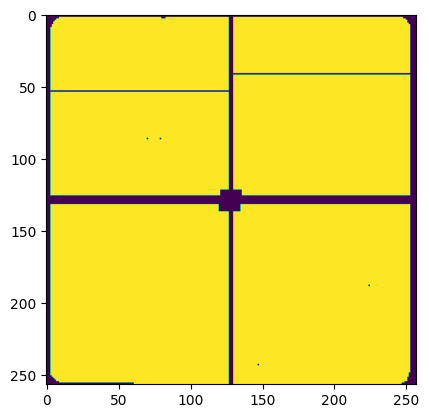

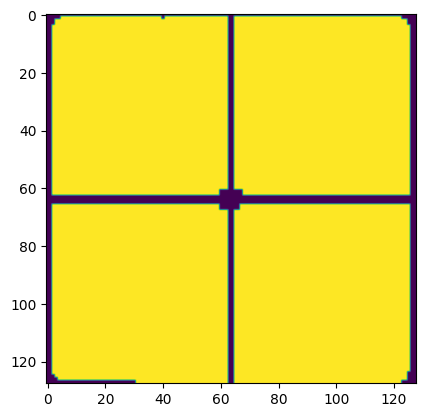

In [21]:
_beam_stop_mask = det[:,-1].reshape(det_shape)[1:-2,:]
beam_stop_mask = torch.zeros(_beam_stop_mask.shape)
beam_stop_mask[_beam_stop_mask!=2] = 1
plt.imshow(beam_stop_mask)

beam_stop_mask_downsampled = scipy.ndimage.zoom(beam_stop_mask, zoom_ratio, order=1)
beam_stop_mask_downsampled[beam_stop_mask_downsampled>=0.5] = 1
beam_stop_mask_downsampled[beam_stop_mask_downsampled<0.5] = 0
plt.figure()
plt.imshow(beam_stop_mask_downsampled)
# torch.save({'mask': torch.from_numpy(beam_stop_mask_downsampled).float()}, f'input/PR772/beam_stop_mask_iUCrJ_{data_type}.pt')